# PyVBMC Example 7: Stacking the posteriors of several runs (S-VBMC)

In this notebook, we combine the variational posteriors of several independent PyVBMC runs into a single *stacked posterior* with S-VBMC (Stacking Variational Bayesian Monte Carlo; Silvestrin, Li & Acerbi, 2025).

Running PyVBMC several times from different starting points is standard practice to check that the runs agree (see Example 4). When they do not, for instance because the posterior is multimodal and each run captures only some of the modes, S-VBMC pools the mixture components of all runs and optimizes their weights against the *stacked ELBO*, using the expected log-joint statistics that every run already stores. Stacking therefore needs **no further evaluations of the model**.

This notebook is Part 7 of a series of notebooks in which we present various example usages for VBMC with the PyVBMC package. S-VBMC needs the optional `torch` dependency: install it with `pip install "pyvbmc[torch]"` (see the installation instructions for a CPU-only torch).

In [2]:
import numpy as np
import scipy.stats as scs
from scipy.special import logsumexp
import matplotlib.pyplot as plt

from pyvbmc import VBMC, SVBMC
from pyvbmc.svbmc.utils import find_init_bounds, overlay_corner_plot

## 1. Model definition: a bimodal target

We take a two-dimensional target with two well-separated modes, an equal mixture of two Gaussians, as a stand-in for a multimodal posterior. Since we know the target, we can later compare the individual runs and the stacked posterior against ground-truth samples. As usual, PyVBMC only needs the unnormalized log density (the log-joint), here defined directly.

In [3]:
D = 2
modes = np.array([[-2.5, -2.5], [2.5, 2.5]])
mode_sd = 0.8


def log_joint(x):
    x = np.atleast_2d(x)
    log_comps = np.stack(
        [scs.norm.logpdf(x, m, mode_sd).sum(axis=1) for m in modes], axis=1
    )
    return logsumexp(log_comps, axis=1) + np.log(0.5)


def sample_truth(n, rng):
    which = rng.integers(len(modes), size=n)
    return modes[which] + mode_sd * rng.standard_normal((n, D))


LB = np.full((1, D), -10.0)  # hard bounds
UB = np.full((1, D), 10.0)
PLB = np.full((1, D), -5.0)  # plausible bounds
PUB = np.full((1, D), 5.0)

## 2. Run PyVBMC several times

We start each run from a different random point in the plausible box. `find_init_bounds` returns the box to draw starting points from (the plausible bounds when given, else the bounds). We run four times with different seeds and keep the returned posteriors. Each posterior carries the run's ELBO estimate and its uncertainty, whether PyVBMC judged the run converged (`stable`), and the expected log-joint statistics that stacking needs. S-VBMC keeps only the converged runs whose expected log-joint is precise enough, and uses their ELBOs to initialize the weights.

In [4]:
n_runs = 4
rng = np.random.default_rng(0)
sample_lb, sample_ub = find_init_bounds(LB, UB, PLB, PUB)

vps = []
for i in range(n_runs):
    x0 = rng.uniform(sample_lb, sample_ub, size=(1, D))
    vbmc = VBMC(
        log_joint, x0, LB, UB, PLB, PUB, options={"display": "off"}, seed=i
    )
    vp, results = vbmc.optimize()
    vps.append(vp)
    print(
        f"Run {i}: x0 = {np.round(x0.ravel(), 2)}, "
        f"ELBO = {vp.stats['elbo']:.3f} +/- {vp.stats['elbo_sd']:.3f}, "
        f"converged: {vp.stats['stable']}"
    )

Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -0.697 +/-0.001.


Run 0: x0 = [ 1.37 -2.3 ], ELBO = -0.697 +/- 0.001, converged: True


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -0.694 +/-0.001.


...

Estimated ELBO: -0.693 +/-0.001.


Run 2: x0 = [3.13 4.13], ELBO = -0.693 +/- 0.001, converged: True


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: 0.003 +/-0.001.


Run 3: x0 = [1.07 2.29], ELBO = 0.003 +/- 0.001, converged: True


The target is normalized, so its log evidence is 0. A run that captures a single mode misses half of the probability mass and reports an ELBO close to $\log(1/2) \approx -0.69$; a run that captures both modes reports an ELBO close to 0. Every run is converged by PyVBMC's criteria, which judge the stability of the solution found, not whether every mode was found: this is exactly the situation stacking is for.

## 3. Stack the posteriors

`SVBMC` takes the list of posteriors. It discards runs that did not converge or whose expected log-joint is too uncertain (`s_max=np.sqrt(5)` by default), and raises an error if fewer than `M_min` runs remain (`M_min=2/3`, so the default requires two thirds of the input runs). `optimize()` maximizes the stacked ELBO with respect to the weights of all pooled components (`version="all-weights"`, the default; `"posterior-only"` optimizes one weight per run instead, and `"ns"` skips the optimization and equally weights the retained runs while preserving each run's internal weights). It works in place and returns `None`.

The `seed` argument fixes the object's random generator, which drives the Monte Carlo entropy estimate and the sampling below; the input posteriors are never modified. The keyword-only `noisy` argument defaults to `None`, which uses the noise status recorded by each retained run. For an older posterior without that metadata, S-VBMC infers that the run is noisy when `vp.stats["elbo_sd"] > 0.1` and records that provenance as `"inferred"`. Setting `noisy=True` or `noisy=False` overrides the whole stack. The keyword-only `show_tips=True` default enables occasional guidance when INFO logging is also enabled; `show_tips=False` suppresses those tips while retaining progress and cap messages.

In [5]:
stacked = SVBMC(vps, seed=0)
stacked.optimize(n_samples_final=100)

print("Headline stacked ELBO:", round(stacked.elbo, 3))
print("SD of the raw estimate: ", round(stacked.elbo_sd, 3))
print("Headline method:        ", stacked.elbo_details["headline_method"])
print("Raw ELBO:               ", round(stacked.elbo_details["raw"], 3))
print("Noise status source:    ", stacked.noise_status_source)

# Total weight assigned to each retained run:
offsets = np.concatenate([[0], np.cumsum(stacked.K)])
for m in range(stacked.M):
    share = stacked.w[0, offsets[m] : offsets[m + 1]].sum()
    print(f"Run {m}: total weight {share:.3f}")

Got 4 well-converged runs after filters.


Tip: Start the individual VBMC runs from different points to help them explore different regions of the posterior.
Optimizing the stacked ELBO w.r.t. all weights.


Initial elbo = 0.011738159792996417


iter 5: elbo = 0.06903267525353085


iter 10: elbo = 0.01648253518926568


Headline stacked ELBO: 0.024
SD of the raw estimate:  0.013
Headline method:         raw
Raw ELBO:                0.024
Noise status source:     ('recorded', 'recorded', 'recorded', 'recorded')
Run 0: total weight 0.242
Run 1: total weight 0.170
Run 2: total weight 0.154
Run 3: total weight 0.434


The scalar `stacked.elbo` is the headline estimate. This target is noiseless, so S-VBMC selects the fresh, uncapped `"raw"` evaluation at the returned weights; its true log evidence is 0. If any retained run is noisy, it instead selects `"capped_I_median"`, which caps the expected log-joint at the median component value to reduce one source of optimistic bias. The cap does not eliminate every source of bias. `stacked.elbo_details` also reports `"capped_E_median"`, which uses the retained-run median, and `"naive"`, which gives each retained run equal total weight while preserving its original internal weights. The naive value inherits errors in the input runs and is a diagnostic baseline, not a bound on the optimized ELBO.

The reported `stacked.elbo_sd` equals `stacked.elbo_details["raw_sd"]`. It combines the Monte Carlo uncertainty of the stratified entropy estimate (`"entropy_sd"`) and GP quadrature uncertainty (`"gp_sd"`) for the uncapped evaluation at the selected weights, treating runs as independent. It excludes selection bias and does not propagate the median cap, so it is not a calibrated confidence interval for a capped headline. `"cap_amount"` records the reduction applied to the headline, and `"noisy"` and `"noise_status_source"` record the noise decision and its provenance. `optimize()` uses `n_samples_final=100` fresh entropy draws per component for this report by default; the keyword-only value must be an integer of at least 2.

In earlier releases, `stacked.elbo` was a dictionary. Migrate `stacked.elbo["estimated"]` to `stacked.elbo_details["raw"]`, `stacked.elbo["debiased_I_median"]` to `stacked.elbo_details["capped_I_median"]`, and `stacked.elbo["debiased_E_median"]` to `stacked.elbo_details["capped_E_median"]`. Use scalar `stacked.elbo` for the automatically selected headline.

## 4. Sample from the stacked posterior

Each run works in its own transformed parameter space, so the mixture components of different runs are **not** directly comparable and the stacked posterior is not a single Gaussian mixture in the original space. Always use `stacked.sample(n)` for estimates and plots: it returns `n` independent draws in the original parameter space (a run is picked at random by its total weight, then a point from that run's components under the optimized weights).

Below we compare samples from the individual runs, from the stacked posterior and from the true target with `overlay_corner_plot`.

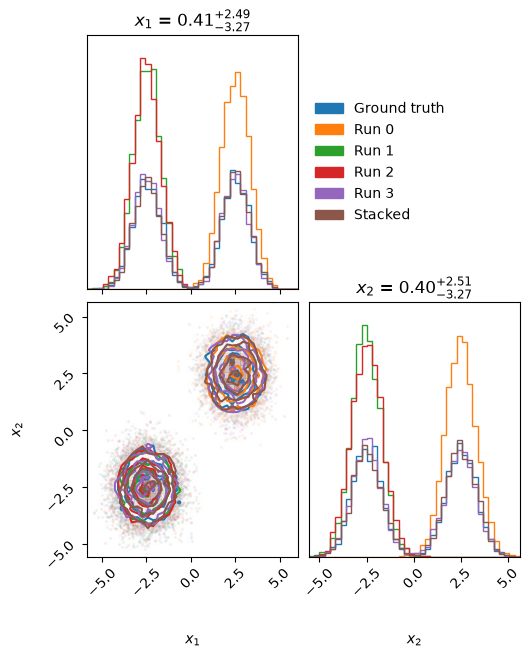

In [6]:
n_samples = 5000
samples = [sample_truth(n_samples, rng)]
labels = ["Ground truth"]
for vp in stacked.vp_list:  # the runs that passed the filters
    samples.append(vp.sample(n_samples)[0])
    labels.append(f"Run {vps.index(vp)}")
samples.append(stacked.sample(n_samples))
labels.append("Stacked")

fig = overlay_corner_plot(samples, labels=labels, figsize=(7, 7), bins=40)

A run that found a single mode places all of its mass there, while the stacked posterior recovers both modes in the right proportions. `stacked.plot()` draws the corner plot of the stacked posterior alone:

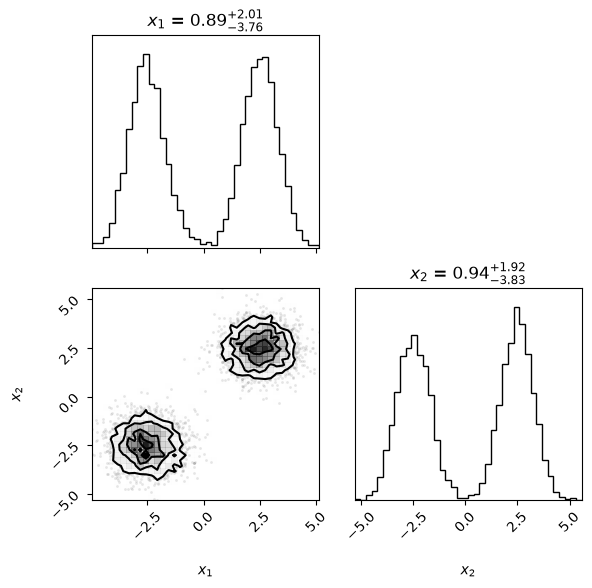

In [7]:
fig = stacked.plot(n_samples=n_samples, figsize=(6, 6), bins=40)

## 5. Conclusions

- Run PyVBMC several times on the same model and data, then pass the returned posteriors to `SVBMC` and call `optimize()`; the stacked posterior needs no new model evaluations.
- Read the headline estimate of the log model evidence from scalar `stacked.elbo`; inspect `stacked.elbo_details` for the raw, capped and naive diagnostics, and interpret `stacked.elbo_sd` as uncertainty of the uncapped evaluation at the selected weights.
- The runs must describe the same model, data and parameter space; the object cannot check this.
- `stacked.sample(n, balance_flag=True)` splits the draws across runs and components in exact proportion to the weights (a stratified sample with lower variance for expectations, not an independent one).

For details, see the S-VBMC paper: Silvestrin, F., Li, C., & Acerbi, L. (2025). Stacking Variational Bayesian Monte Carlo. *Transactions on Machine Learning Research*. [arXiv:2504.05004](https://arxiv.org/abs/2504.05004). Please cite it together with the VBMC and PyVBMC papers when you use S-VBMC.

## Acknowledgments

Work on the PyVBMC package was funded by the [Finnish Center for Artificial Intelligence FCAI](https://fcai.fi/).